Libraries

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from adjustText import adjust_text
import matplotlib.patches as mpatches

Paths

In [2]:
QUERIES_DIR = "data/results/queries"
MODELS_DIR = "data/results/models"

# Join Results

## Queries

In [3]:
queries_rows = []

for file_name in os.listdir(QUERIES_DIR):

    if file_name.endswith(".json"):

        file_path = os.path.join(QUERIES_DIR, file_name)

        with open(file_path, "r") as f:
            data = json.load(f)

        for run in data.get("runs", []):

            base_info = {
                "timestamp": run.get("timestamp"),
                "spark_mode": run.get("spark_mode"),

                "executor_instances": run.get("spark_config", {}).get("executor_instances"),
                "executor_cores": run.get("spark_config", {}).get("executor_cores"),
                "executor_memory": run.get("spark_config", {}).get("executor_memory"),
                "shuffle_partitions": run.get("spark_config", {}).get("shuffle_partitions"),
                "adaptive": run.get("spark_config", {}).get("adaptive")
            }

            for metric in run.get("metrics", []):

                row = {
                    **base_info,

                    "query_description": metric.get("Query Description"),
                    "api_time_s": metric.get("API Time (s)"),
                    "sql_time_s": metric.get("SQL Time (s)"),
                    "time_delta": metric.get("Time Delta (SQL - API)")
                }

                queries_rows.append(row)

df_queries = pd.DataFrame(queries_rows)

## Models

In [4]:
models_rows = []

for file_name in os.listdir(MODELS_DIR):

    if file_name.endswith(".json"):

        file_path = os.path.join(MODELS_DIR, file_name)

        with open(file_path, "r") as f:
            data = json.load(f)

        for run in data.get("runs", []):

            base_info = {
                "timestamp": run.get("timestamp"),
                "spark_mode": run.get("spark_mode"),

                "executor_instances": run.get("spark_config", {}).get("executor_instances"),
                "executor_cores": run.get("spark_config", {}).get("executor_cores"),
                "executor_memory": run.get("spark_config", {}).get("executor_memory"),
                "shuffle_partitions": run.get("spark_config", {}).get("shuffle_partitions"),
                "adaptive": run.get("spark_config", {}).get("adaptive")
            }

            for result in run.get("model_results", []):

                metrics = result.get("metrics", {})

                row = {
                    **base_info,

                    "model_name": result.get("model_name"),
                    "target": result.get("target"),
                    "task_type": result.get("task_type"),

                    "rmse": metrics.get("rmse"),
                    "r2": metrics.get("r2"),
                    "mae": metrics.get("mae"),
                    "mse": metrics.get("mse"),

                    "execution_time_seconds": result.get("execution_time_seconds")
                }

                models_rows.append(row)

df_models = pd.DataFrame(models_rows)

## Preview

In [5]:
print("\n==============================")
print("QUERIES DATAFRAME")
print("==============================")
print(df_queries.head())

print("\nShape:", df_queries.shape)

print("\n==============================")
print("MODELS DATAFRAME")
print("==============================")
print(df_models.head())

print("\nShape:", df_models.shape)


QUERIES DATAFRAME
             timestamp spark_mode  executor_instances  executor_cores  \
0  2026-05-17 17:16:55   baseline                   2               1   
1  2026-05-17 17:16:55   baseline                   2               1   
2  2026-05-17 17:16:55   baseline                   2               1   
3  2026-05-17 17:16:55   baseline                   2               1   
4  2026-05-17 17:16:55   baseline                   2               1   

  executor_memory  shuffle_partitions  adaptive  \
0              3g                  50     False   
1              3g                  50     False   
2              3g                  50     False   
3              3g                  50     False   
4              3g                  50     False   

                         query_description  api_time_s  sql_time_s  time_delta  
0  Q1.1: Borough Revenue vs Tip Percentage      5.0557      7.2595      2.2038  
1            Q1.2: Tip Paradox by Distance      5.3696      4.5349     -0

In [6]:
df_queries['query_id'] = df_queries['query_description'].apply(lambda x: x.split(':')[0])

### Colors

In [7]:
COLOR_API = "#faba71"
COLOR_SQL = "#a1301c"
BG_COLOR = "#ffffff"

SCENARIO_COLORS = {
    'aqe_only': '#457b9d',
    'balanced': '#f4a261',
    'baseline': '#2a9d8f',
    'cpu_heavy': '#e76f51',
    'high_parallelism': '#9b5de5',
    'low_overhead': '#8d99ae',
    'memory_optimized': '#f15bb5',
    'stress_test': '#00b4d8'
}

MODEL_COLORS = {
    'RandomForest': "#0d67a3",
    'GeneralizedLinearModel': "#d1495b",
    'LinearRegression': "#11b1ce",
    'DecisionTree': "#edae49",
    'GBT': "#84e4b1"
}

# Queries Analysis

/tmp/ipykernel_507849/3435423976.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.88])


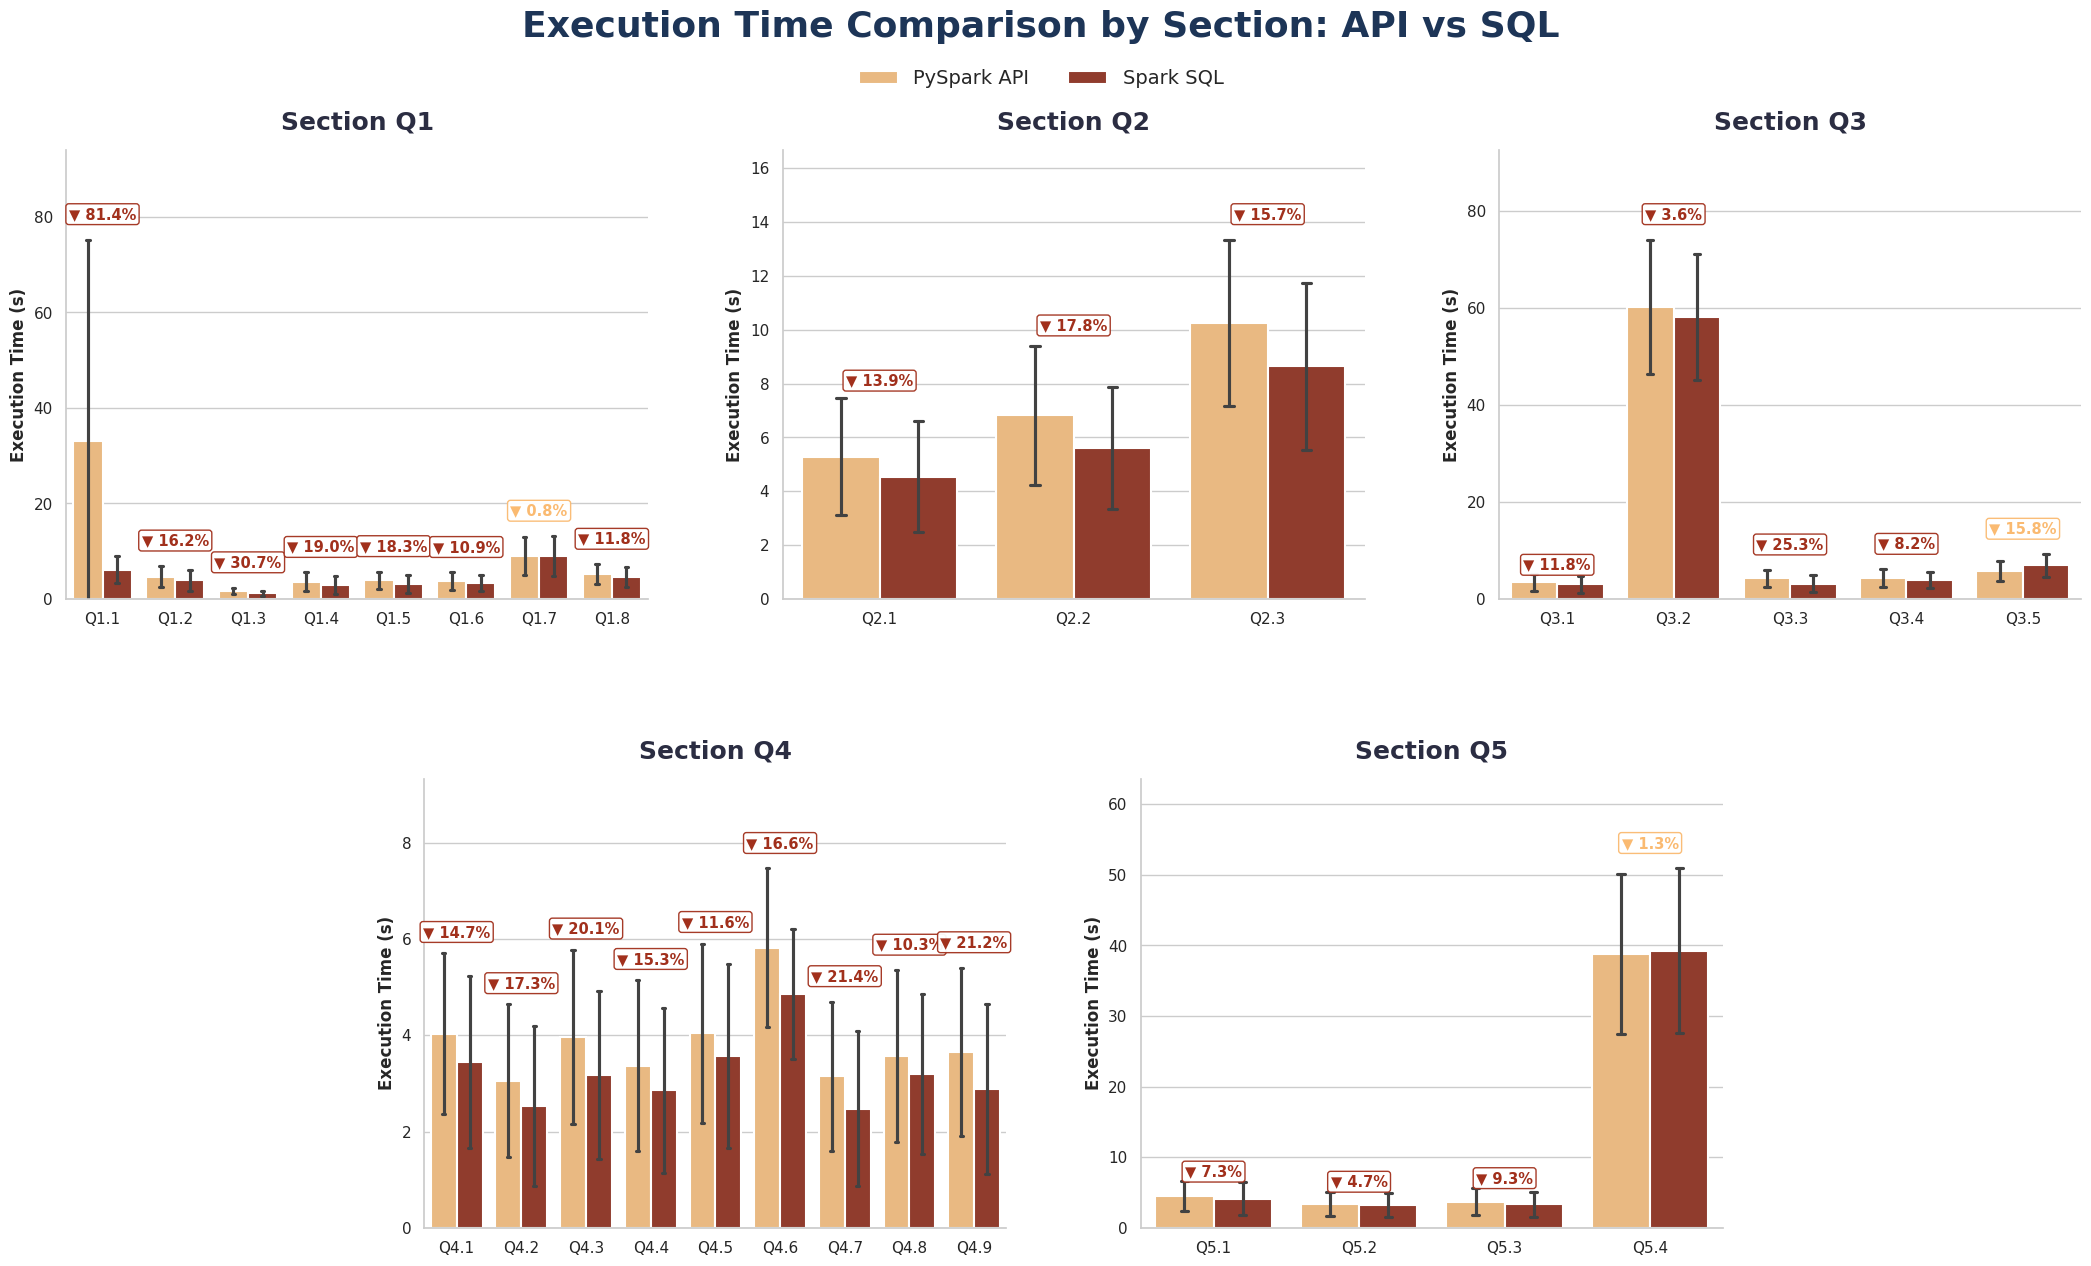

In [8]:
sns.set_theme(style="whitegrid")

df_queries['query_id'] = df_queries['query_description'].apply(lambda x: x.split(':')[0].strip())
df_queries['section'] = df_queries['query_id'].apply(lambda x: x.split('.')[0].strip())

sections = sorted(df_queries['section'].unique())

fig = plt.figure(figsize=(26, 14), facecolor=BG_COLOR)
fig.suptitle("Execution Time Comparison by Section: API vs SQL", 
             fontsize=26, fontweight='900', color='#1d3557', y=0.98)

gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=0.6)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])

axes = [ax1, ax2, ax3, ax4, ax5]

for i, sec in enumerate(sections[:5]):
    ax = axes[i]
    df_sec = df_queries[df_queries['section'] == sec].copy()

    query_order = sorted(df_sec['query_id'].unique())

    df_melt = df_sec.melt(
        id_vars=['query_id'],
        value_vars=['api_time_s', 'sql_time_s'],
        var_name='method',
        value_name='time'
    )

    sns.barplot(
        data=df_melt,
        x='query_id',
        y='time',
        hue='method',
        order=query_order,
        palette={'api_time_s': COLOR_API, 'sql_time_s': COLOR_SQL},
        edgecolor='white',
        linewidth=1.5,
        errorbar='sd',
        capsize=0.1,
        ax=ax
    )

    max_height_in_plot = 0

    for idx, q_id in enumerate(query_order):
        api_data = df_sec[df_sec['query_id'] == q_id]['api_time_s']
        sql_data = df_sec[df_sec['query_id'] == q_id]['sql_time_s']

        api_mean, api_std = api_data.mean(), api_data.std()
        sql_mean, sql_std = sql_data.mean(), sql_data.std()

        api_std = 0 if pd.isna(api_std) else api_std
        sql_std = 0 if pd.isna(sql_std) else sql_std

        api_top = api_mean + api_std
        sql_top = sql_mean + sql_std

        local_max = max(api_top, sql_top)

        if local_max > max_height_in_plot:
            max_height_in_plot = local_max

        if api_mean < sql_mean:
            win_color = COLOR_API
            pct_diff = ((sql_mean - api_mean) / sql_mean) * 100
            label_text = f"▼ {pct_diff:.1f}%"
        else:
            win_color = COLOR_SQL
            pct_diff = ((api_mean - sql_mean) / api_mean) * 100
            label_text = f"▼ {pct_diff:.1f}%"

        ax.text(
            x=idx,
            y=local_max + (max_height_in_plot * 0.05),
            s=label_text,
            ha='center',
            va='bottom',
            color=win_color,
            fontweight='900',
            fontsize=10.5,
            bbox=dict(facecolor='white', edgecolor=win_color, boxstyle='round,pad=0.2', alpha=0.95)
        )

    ax.set_title(f"Section {sec}", fontsize=18, fontweight='bold', color='#2b2d42', pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("Execution Time (s)", fontsize=12, fontweight='bold')

    ax.set_ylim(0, max_height_in_plot * 1.25)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

for j in range(len(sections), 5):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    ['PySpark API', 'Spark SQL'],
    loc='upper center',
    bbox_to_anchor=(0.5, 0.95),
    ncol=2,
    frameon=False,
    fontsize=14
)

plt.tight_layout(rect=[0, 0.03, 1, 0.88])
plt.show()

/tmp/ipykernel_507849/1165613862.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])


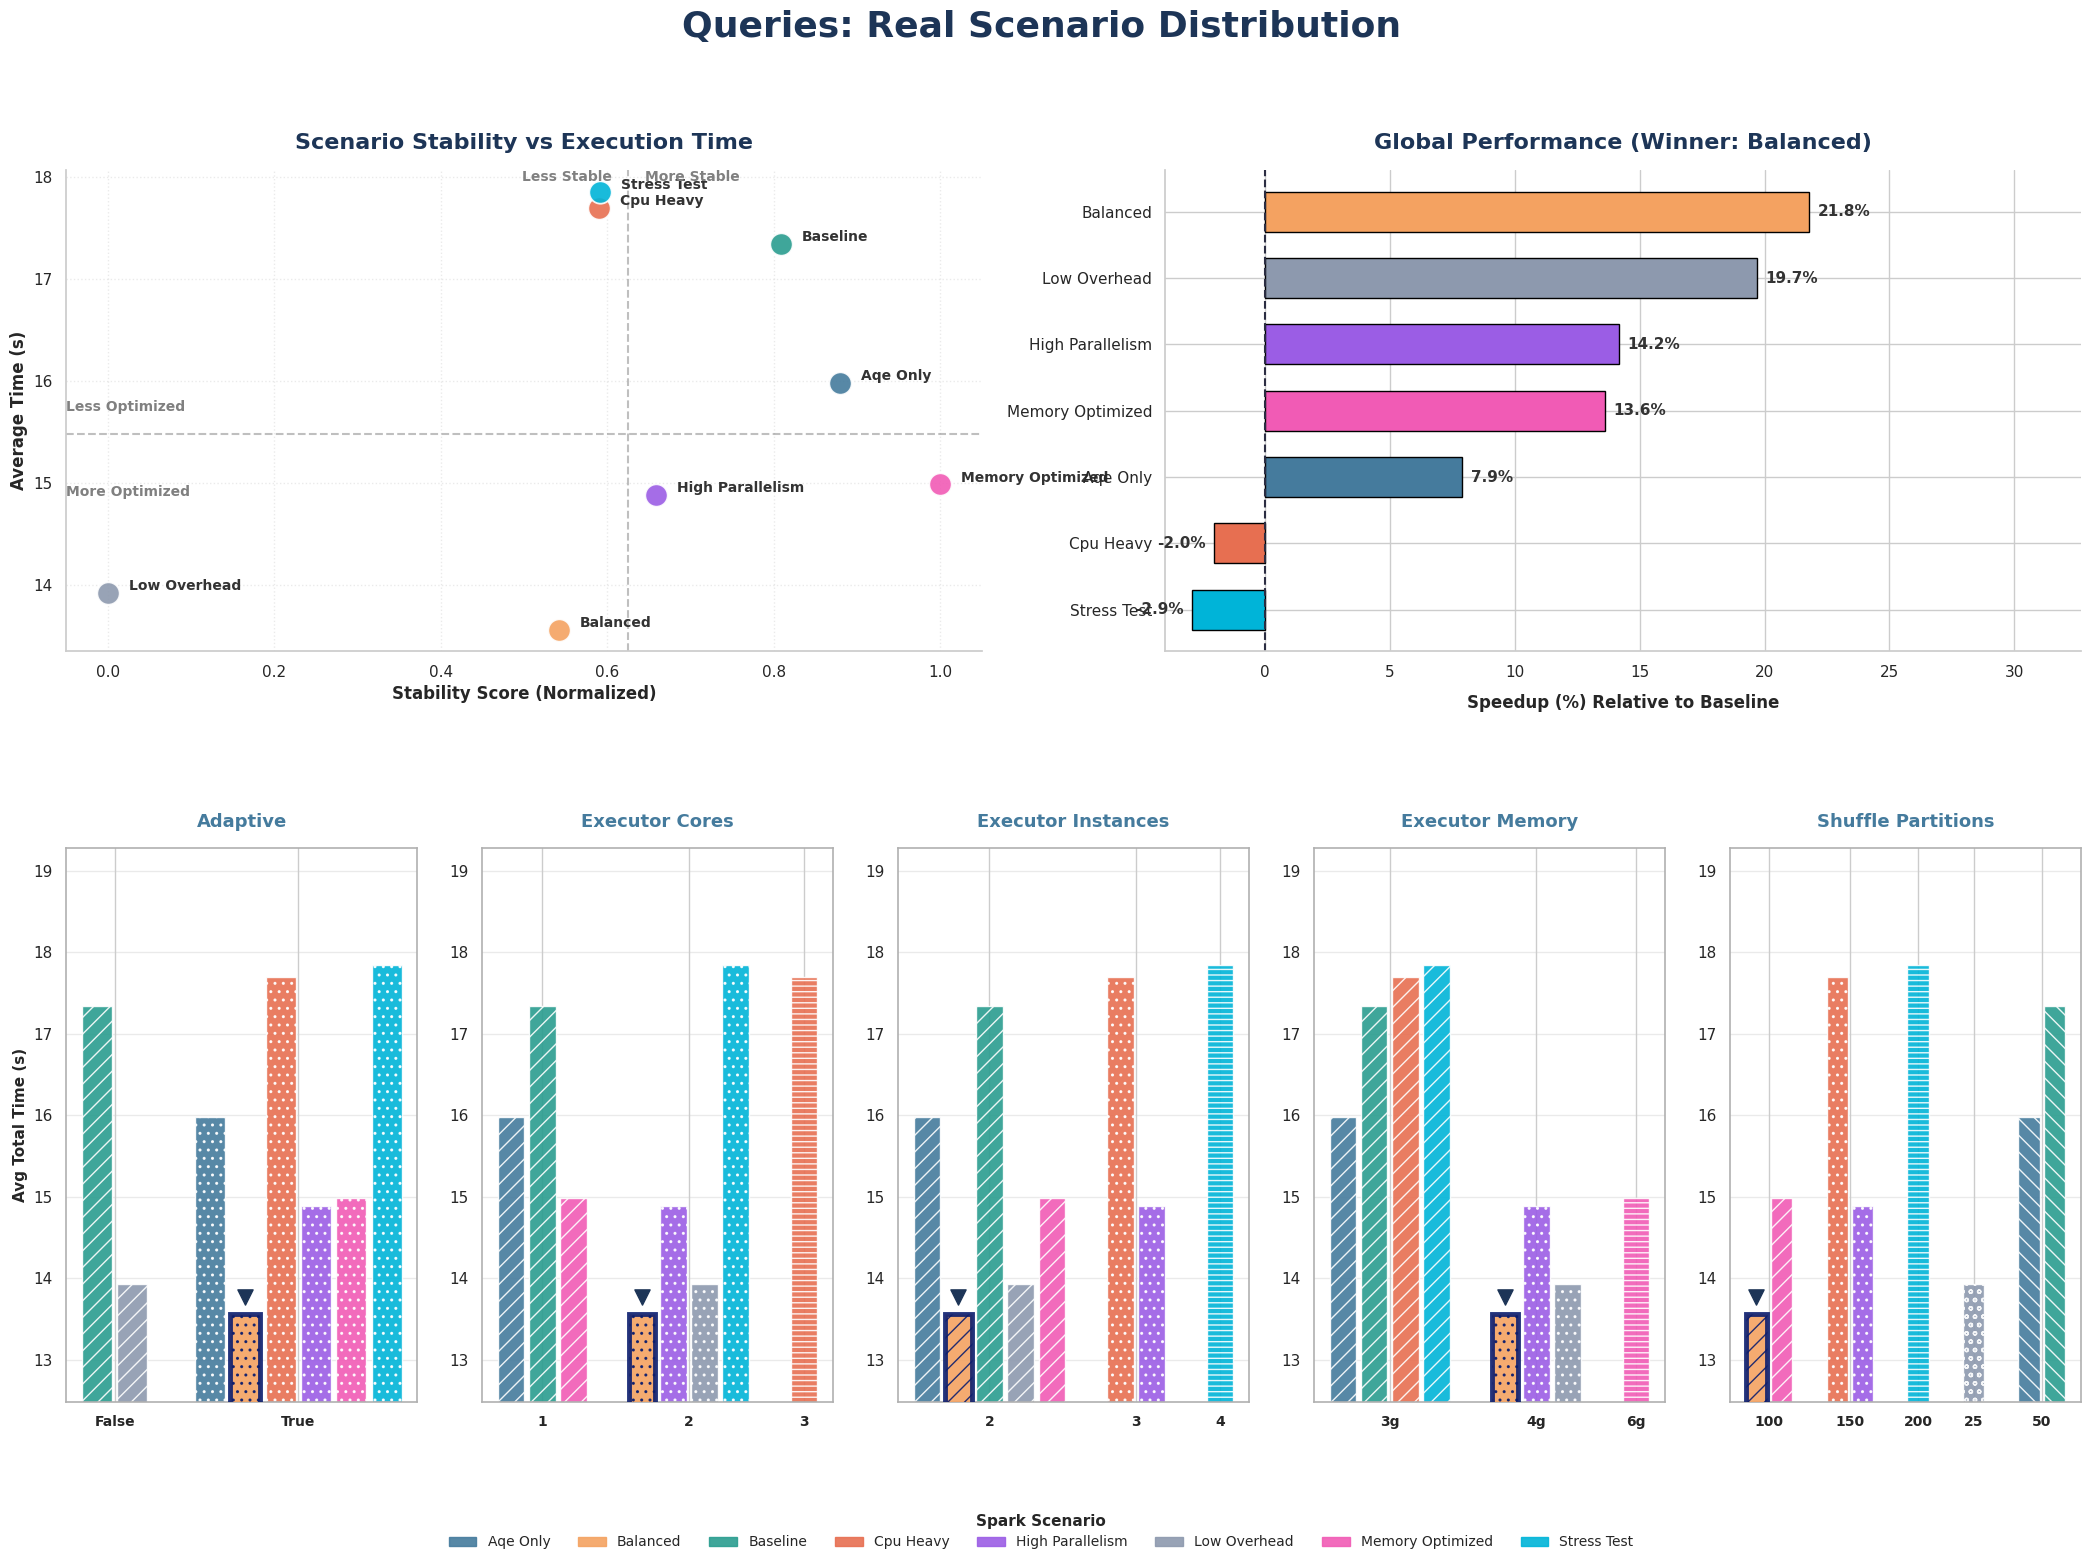

In [9]:
# DATA PREPARATION

df_queries['query_id'] = df_queries['query_description'].apply(lambda x: x.split(':')[0].strip())
df_queries['section'] = df_queries['query_id'].apply(lambda x: x.split('.')[0].strip())

if 'total_time_s' not in df_queries.columns:
    df_queries['total_time_s'] = df_queries['sql_time_s'] + df_queries['api_time_s']

# GLOBAL PERFORMANCE

scenario_perf = df_queries.groupby('spark_mode')['total_time_s'].mean().reset_index()

baseline_time = scenario_perf[
    scenario_perf['spark_mode'] == 'baseline'
]['total_time_s'].values[0]

scenario_perf['improvement_pct'] = (
    (
        baseline_time -
        scenario_perf['total_time_s']
    )
    /
    baseline_time
) * 100

scenario_perf = scenario_perf[scenario_perf['spark_mode'] != 'baseline']

scenario_perf = scenario_perf.sort_values(by='improvement_pct',ascending=True)

best_scenario_name = (scenario_perf.iloc[-1]['spark_mode'])

best_config = df_queries[df_queries['spark_mode'] == best_scenario_name].iloc[0]

# STABILITY METRIC

stability_df = df_queries.groupby("spark_mode")["total_time_s"].agg(["mean", "std"]).reset_index()

stability_df["stability_score"] = 1 / (stability_df["std"] + 1e-6)

stability_df["stability_score_norm"] = (
    (stability_df["stability_score"] - stability_df["stability_score"].min()) /
    (stability_df["stability_score"].max() - stability_df["stability_score"].min())
)

# SCENARIO AGGREGATION

component_cols = [
    'adaptive',
    'executor_cores',
    'executor_instances',
    'executor_memory',
    'shuffle_partitions'
]

cols_to_group = ['spark_mode'] + component_cols

df_scenarios = df_queries.groupby(cols_to_group)['total_time_s'].mean().reset_index()

scenarios = sorted(df_scenarios['spark_mode'].unique())

feature_hatch_patterns = [
    '//',
    '..',
    '---',
    'oo',
    '\\\\'
]

global_min_time = (df_scenarios['total_time_s'].min())

# FIGURE LAYOUT

fig = plt.figure(figsize=(26, 16), facecolor=BG_COLOR)

fig.suptitle("Queries: Real Scenario Distribution", fontsize=26, fontweight='900', color='#1d3557', y=0.98)

gs_main = fig.add_gridspec(2, 1, height_ratios=[1, 1.15], hspace=0.38)

gs_top = gs_main[0].subgridspec(1, 2, wspace=0.20)

gs_bottom = gs_main[1].subgridspec(1, 10, wspace=0.45)

# Plot 1

ax_top = fig.add_subplot(gs_top[0, 0])

median_stab = stability_df["stability_score_norm"].median()
median_time = stability_df["mean"].median()

ax_top.axvline(median_stab, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

ax_top.axhline(median_time, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

for _, row in stability_df.iterrows():

    scenario = row["spark_mode"]

    x = row["stability_score_norm"]
    y = row["mean"]

    ax_top.scatter(x, y, s=260, color=SCENARIO_COLORS.get(scenario, '#cccccc'), edgecolor="white", linewidth=1.3, alpha=0.9, zorder=3 )

    ax_top.text(x + 0.025, y, scenario.replace("_", " ").title(), fontsize=10, fontweight='bold', color='#333333', ha='left', va='bottom' )

ax_top.text(median_stab - 0.02, ax_top.get_ylim()[1], "Less Stable", ha='right', va='top', fontsize=10, fontweight='bold', color='gray')

ax_top.text(median_stab + 0.02, ax_top.get_ylim()[1], "More Stable", ha='left', va='top', fontsize=10, fontweight='bold', color='gray')

ax_top.text(ax_top.get_xlim()[0], median_time + 0.2, "Less Optimized", ha='left', va='bottom', fontsize=10, fontweight='bold', color='gray')

ax_top.text(ax_top.get_xlim()[0], median_time - 0.5, "More Optimized", ha='left', va='top', fontsize=10, fontweight='bold', color='gray')

ax_top.set_title("Scenario Stability vs Execution Time", fontsize=16, fontweight='900', color='#1d3557', pad=15)

ax_top.set_xlabel("Stability Score (Normalized)", fontsize=12, fontweight='bold')

ax_top.set_ylabel("Average Time (s)", fontsize=12, fontweight='bold')

ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)

ax_top.grid(axis='both', linestyle=':', alpha=0.4)

# Plot 2

ax_perf = fig.add_subplot(gs_top[0, 1])

bar_colors = [
    SCENARIO_COLORS.get(mode, '#cccccc')
    for mode in scenario_perf['spark_mode']
]

bars = ax_perf.barh(scenario_perf['spark_mode'].str.replace('_', ' ').str.title(), scenario_perf['improvement_pct'],
                    color=bar_colors, edgecolor='black', height=0.6)

ax_perf.axvline(0, color='#2b2d42', linestyle='--', linewidth=1.5)

ax_perf.set_xlim(-4, scenario_perf['improvement_pct'].max() * 1.5)

ax_perf.bar_label(bars, fmt='%.1f%%', padding=6, fontweight='bold', fontsize=11, color='#333333')

ax_perf.set_title(
    f"Global Performance (Winner: {best_scenario_name.title()})", fontsize=16, color='#1d3557', fontweight='bold', pad=15
)

ax_perf.set_xlabel(
    "Speedup (%) Relative to Baseline", fontsize=12, fontweight='bold', labelpad=10
)

ax_perf.spines['top'].set_visible(False)
ax_perf.spines['right'].set_visible(False)

# Bottom plots

axes = [fig.add_subplot(gs_bottom[0, i*2:(i+1)*2]) for i in range(5)]

y_min = (df_scenarios['total_time_s'].min() * 0.92)

y_max = (df_scenarios['total_time_s'].max() * 1.08)

y_span = y_max - y_min

for ax, comp in zip(axes, component_cols):

    df_queries[comp] = (df_queries[comp].astype(str))

    df_scenarios[comp] = (df_scenarios[comp].astype(str))

    unique_vals = sorted(df_scenarios[comp].unique())

    pattern_mapping = dict(zip(unique_vals, feature_hatch_patterns))

    x_ticks = []
    x_labels = []
    current_x = 0

    for val in unique_vals:

        subset = df_scenarios[df_scenarios[comp] == val]
        group_start = current_x

        for _, row in subset.iterrows():

            scenario = row['spark_mode']

            bar_height = row['total_time_s']

            is_winner = (bar_height == global_min_time )

            bar_edge_color = ("#0B1D6E" if is_winner else 'white' )

            bar_line_width = (3.5 if is_winner else 1 )

            z_order = (10 if is_winner else 2 )

            ax.bar(current_x, bar_height, width=0.85, color=SCENARIO_COLORS.get(scenario, '#cccccc'), hatch=pattern_mapping[val], edgecolor=bar_edge_color, linewidth=bar_line_width, alpha=0.9, zorder=z_order )

            if is_winner:
                ax.scatter(current_x, bar_height + (y_span * 0.03), marker='v', color='#1d3557', s=120, zorder=20 )

            current_x += 1

        group_end = current_x - 1

        if len(subset) > 0:
            x_ticks.append((group_start + group_end) / 2)
            x_labels.append(str(val))

        current_x += 1.2

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=10, fontweight='bold' )
    ax.set_title(comp.replace('_', ' ').title(), fontsize=13, fontweight='bold', pad=15, color='#457b9d')
    ax.set_ylim(y_min, y_max)
    ax.grid(axis='y', linestyle='-', alpha=0.4, zorder=0 )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#b0b0b0')
        spine.set_linewidth(1.2)

    if ax == axes[0]:
        ax.set_ylabel("Avg Total Time (s)", fontsize=11, fontweight='bold')
    else:
        ax.tick_params(axis='y', left=False)

# Labels and Legend
handles = [
    mpatches.Patch( color=SCENARIO_COLORS.get(scen, '#cccccc'), label=scen.replace('_', ' ').title(), alpha=0.9)
    for scen in scenarios
]

fig.legend( handles=handles, title="Spark Scenario",
    title_fontproperties={
        'weight': 'bold',
        'size': 11
    }, loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=8, frameon=False, fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

plt.show()

# Models

/tmp/ipykernel_507849/4080744008.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(ax3.get_xticklabels(), rotation=25, ha='right', fontweight='bold')
/tmp/ipykernel_507849/4080744008.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


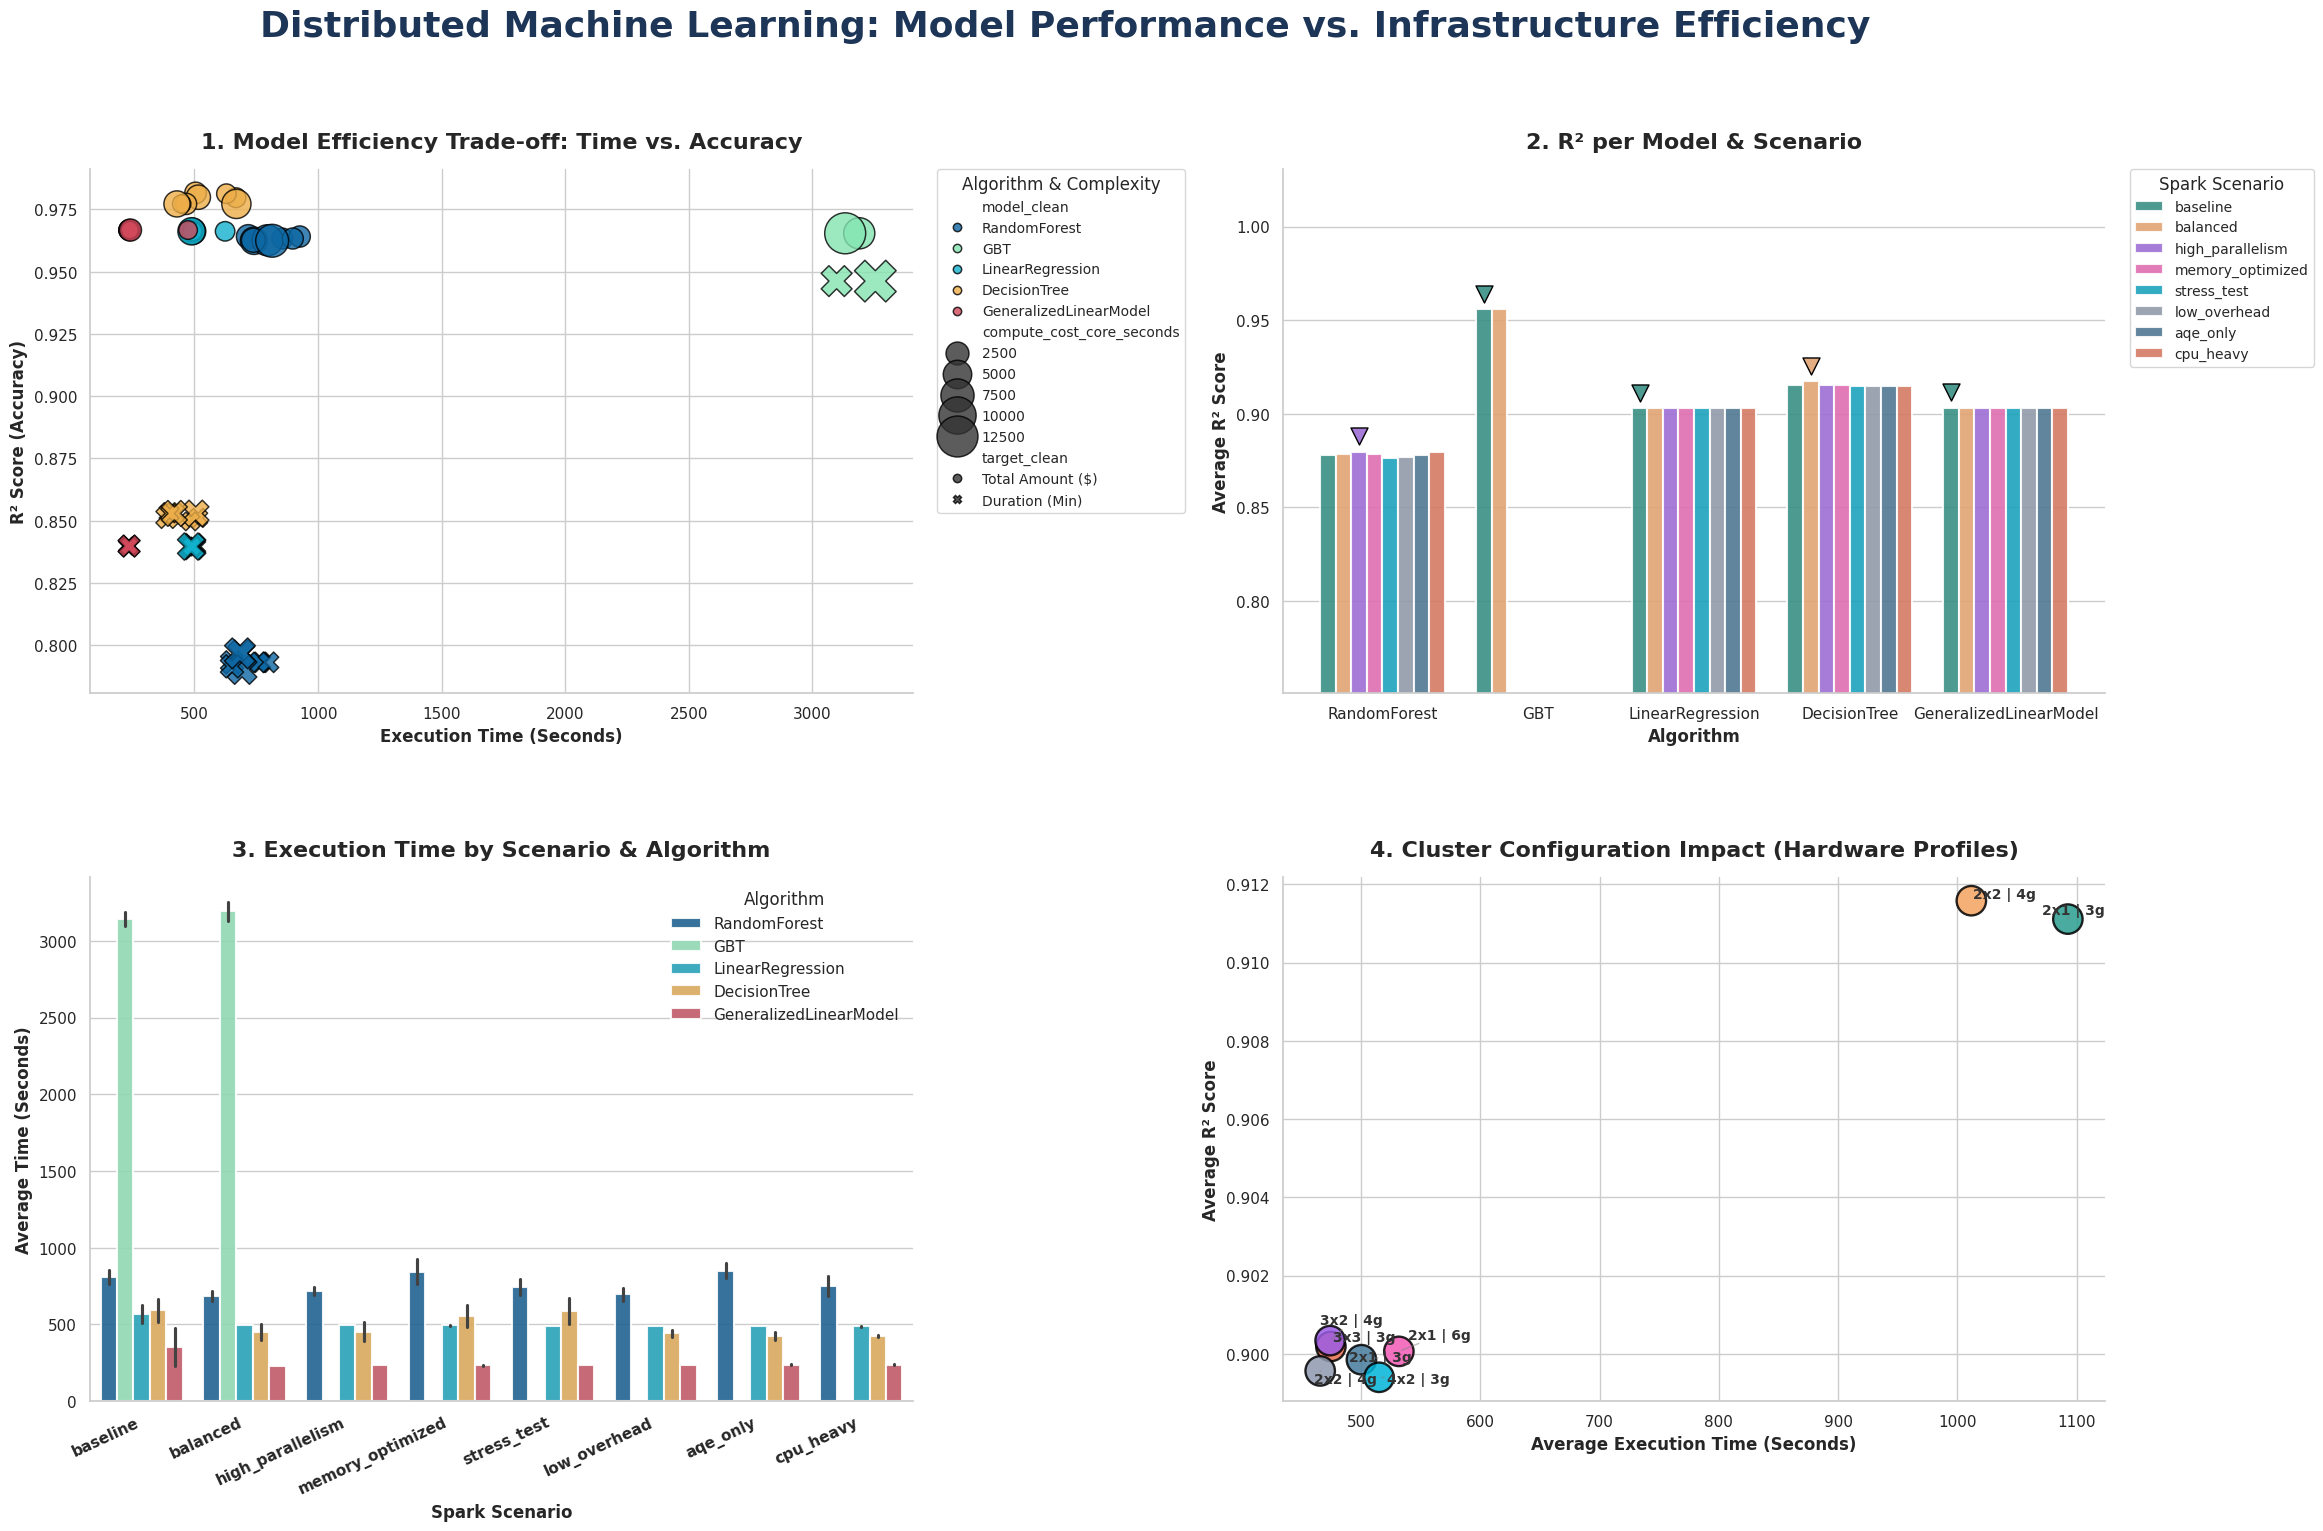

In [10]:
# Data Preparation
df_m = df_models[df_models['task_type'] == 'regression'].copy()

df_m['model_clean'] = df_m['model_name'].str.replace('Regressor', '').str.replace('_Ridge_Std', '')
df_m['target_clean'] = df_m['target'].replace({
    'total_amount': 'Total Amount ($)',
    'trip_duration_min': 'Duration (Min)'
})

df_m["cluster_label"] = (
    df_m["executor_instances"].astype(str) + "x" +
    df_m["executor_cores"].astype(str) + " | " +
    df_m["executor_memory"]
)

df_m['compute_cost_core_seconds'] = (
    df_m['executor_instances'] * df_m['executor_cores'] *
    df_m['execution_time_seconds']
)

cluster_perf = df_m.groupby(["spark_mode", "cluster_label"]).agg({
    "r2": "mean",
    "execution_time_seconds": "mean"
}).reset_index()

# Layout
fig = plt.figure(figsize=(26, 16), facecolor=BG_COLOR)
fig.suptitle("Distributed Machine Learning: Model Performance vs. Infrastructure Efficiency",
             fontsize=26, fontweight='900', color='#1d3557', y=0.98)

gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.45)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Plot 1
sns.scatterplot(
    data=df_m, x='execution_time_seconds', y='r2',
    hue='model_clean', style='target_clean', palette=MODEL_COLORS,
    size='compute_cost_core_seconds', sizes=(150, 900), alpha=0.8, edgecolor='black', ax=ax1
)
ax1.set_title("1. Model Efficiency Trade-off: Time vs. Accuracy", fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel("Execution Time (Seconds)", fontsize=12, fontweight='bold')
ax1.set_ylabel("R² Score (Accuracy)", fontsize=12, fontweight='bold')

sns.move_legend(
    ax1, "upper left",
    bbox_to_anchor=(1.03, 1),
    borderaxespad=0,
    frameon=True,
    fontsize=10,
    title_fontsize=12,
    title="Algorithm & Complexity"
)

# Plot 2
sns.barplot(
    data=df_m, x="model_clean", y="r2", hue="spark_mode",
    palette=SCENARIO_COLORS, edgecolor='white', linewidth=1.5, alpha=0.9,
    errorbar=None, ax=ax2
)
ax2.set_title("2. R² per Model & Scenario", fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel("Algorithm", fontsize=12, fontweight='bold')
ax2.set_ylabel("Average R² Score", fontsize=12, fontweight='bold')

ax2.legend(bbox_to_anchor=(1.03, 1), loc='upper left', title="Spark Scenario",
           frameon=True, borderaxespad=0, fontsize=10, title_fontsize=12)

y_min = df_m['r2'].min() * 0.95
y_max = df_m['r2'].max() * 1.05
ax2.set_ylim(y_min, y_max)
y_span = y_max - y_min

best_patches_per_model = {}

for patch in ax2.patches:
    height = patch.get_height()
    if pd.isna(height) or height == 0:
        continue

    x_center = patch.get_x() + patch.get_width() / 2
    model_idx = round(x_center)

    if model_idx not in best_patches_per_model or height > best_patches_per_model[model_idx].get_height():
        best_patches_per_model[model_idx] = patch

for patch in best_patches_per_model.values():
    x_center = patch.get_x() + patch.get_width() / 2
    bar_color = patch.get_facecolor()

    ax2.scatter(
        x_center, patch.get_height() + (y_span * 0.03),
        marker='v',
        color=bar_color,
        edgecolor='black',
        linewidth=1,
        s=150,
        zorder=10
    )

# Plot 3
sns.barplot(
    data=df_m, x='spark_mode', y='execution_time_seconds', hue='model_clean',
    palette=MODEL_COLORS, edgecolor='white', linewidth=1.5, alpha=0.9, ax=ax3
)
ax3.set_title("3. Execution Time by Scenario & Algorithm", fontsize=16, fontweight='bold', pad=15)
ax3.set_xlabel("Spark Scenario", fontsize=12, fontweight='bold')
ax3.set_ylabel("Average Time (Seconds)", fontsize=12, fontweight='bold')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=25, ha='right', fontweight='bold')

handles, labels = ax3.get_legend_handles_labels()
ax3.legend(handles=handles, labels=labels, title="Algorithm", frameon=False, loc='upper right')

# Plot 4
sns.scatterplot(
    data=cluster_perf,
    x="execution_time_seconds",
    y="r2",
    hue="spark_mode",
    palette=SCENARIO_COLORS,
    s=450,
    alpha=0.85,
    edgecolor='black',
    ax=ax4,
    legend=False
)

texts = []
for _, row in cluster_perf.iterrows():
    t = ax4.text(
        row["execution_time_seconds"], row["r2"],
        row["cluster_label"],
        fontsize=10, fontweight='bold', color='#333333'
    )
    texts.append(t)

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5), ax=ax4)

ax4.set_title("4. Cluster Configuration Impact (Hardware Profiles)", fontsize=16, fontweight='bold', pad=15)
ax4.set_xlabel("Average Execution Time (Seconds)", fontsize=12, fontweight='bold')
ax4.set_ylabel("Average R² Score", fontsize=12, fontweight='bold')

# Clean up
for ax in [ax1, ax2, ax3, ax4]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_507849/123223703.py:193: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])


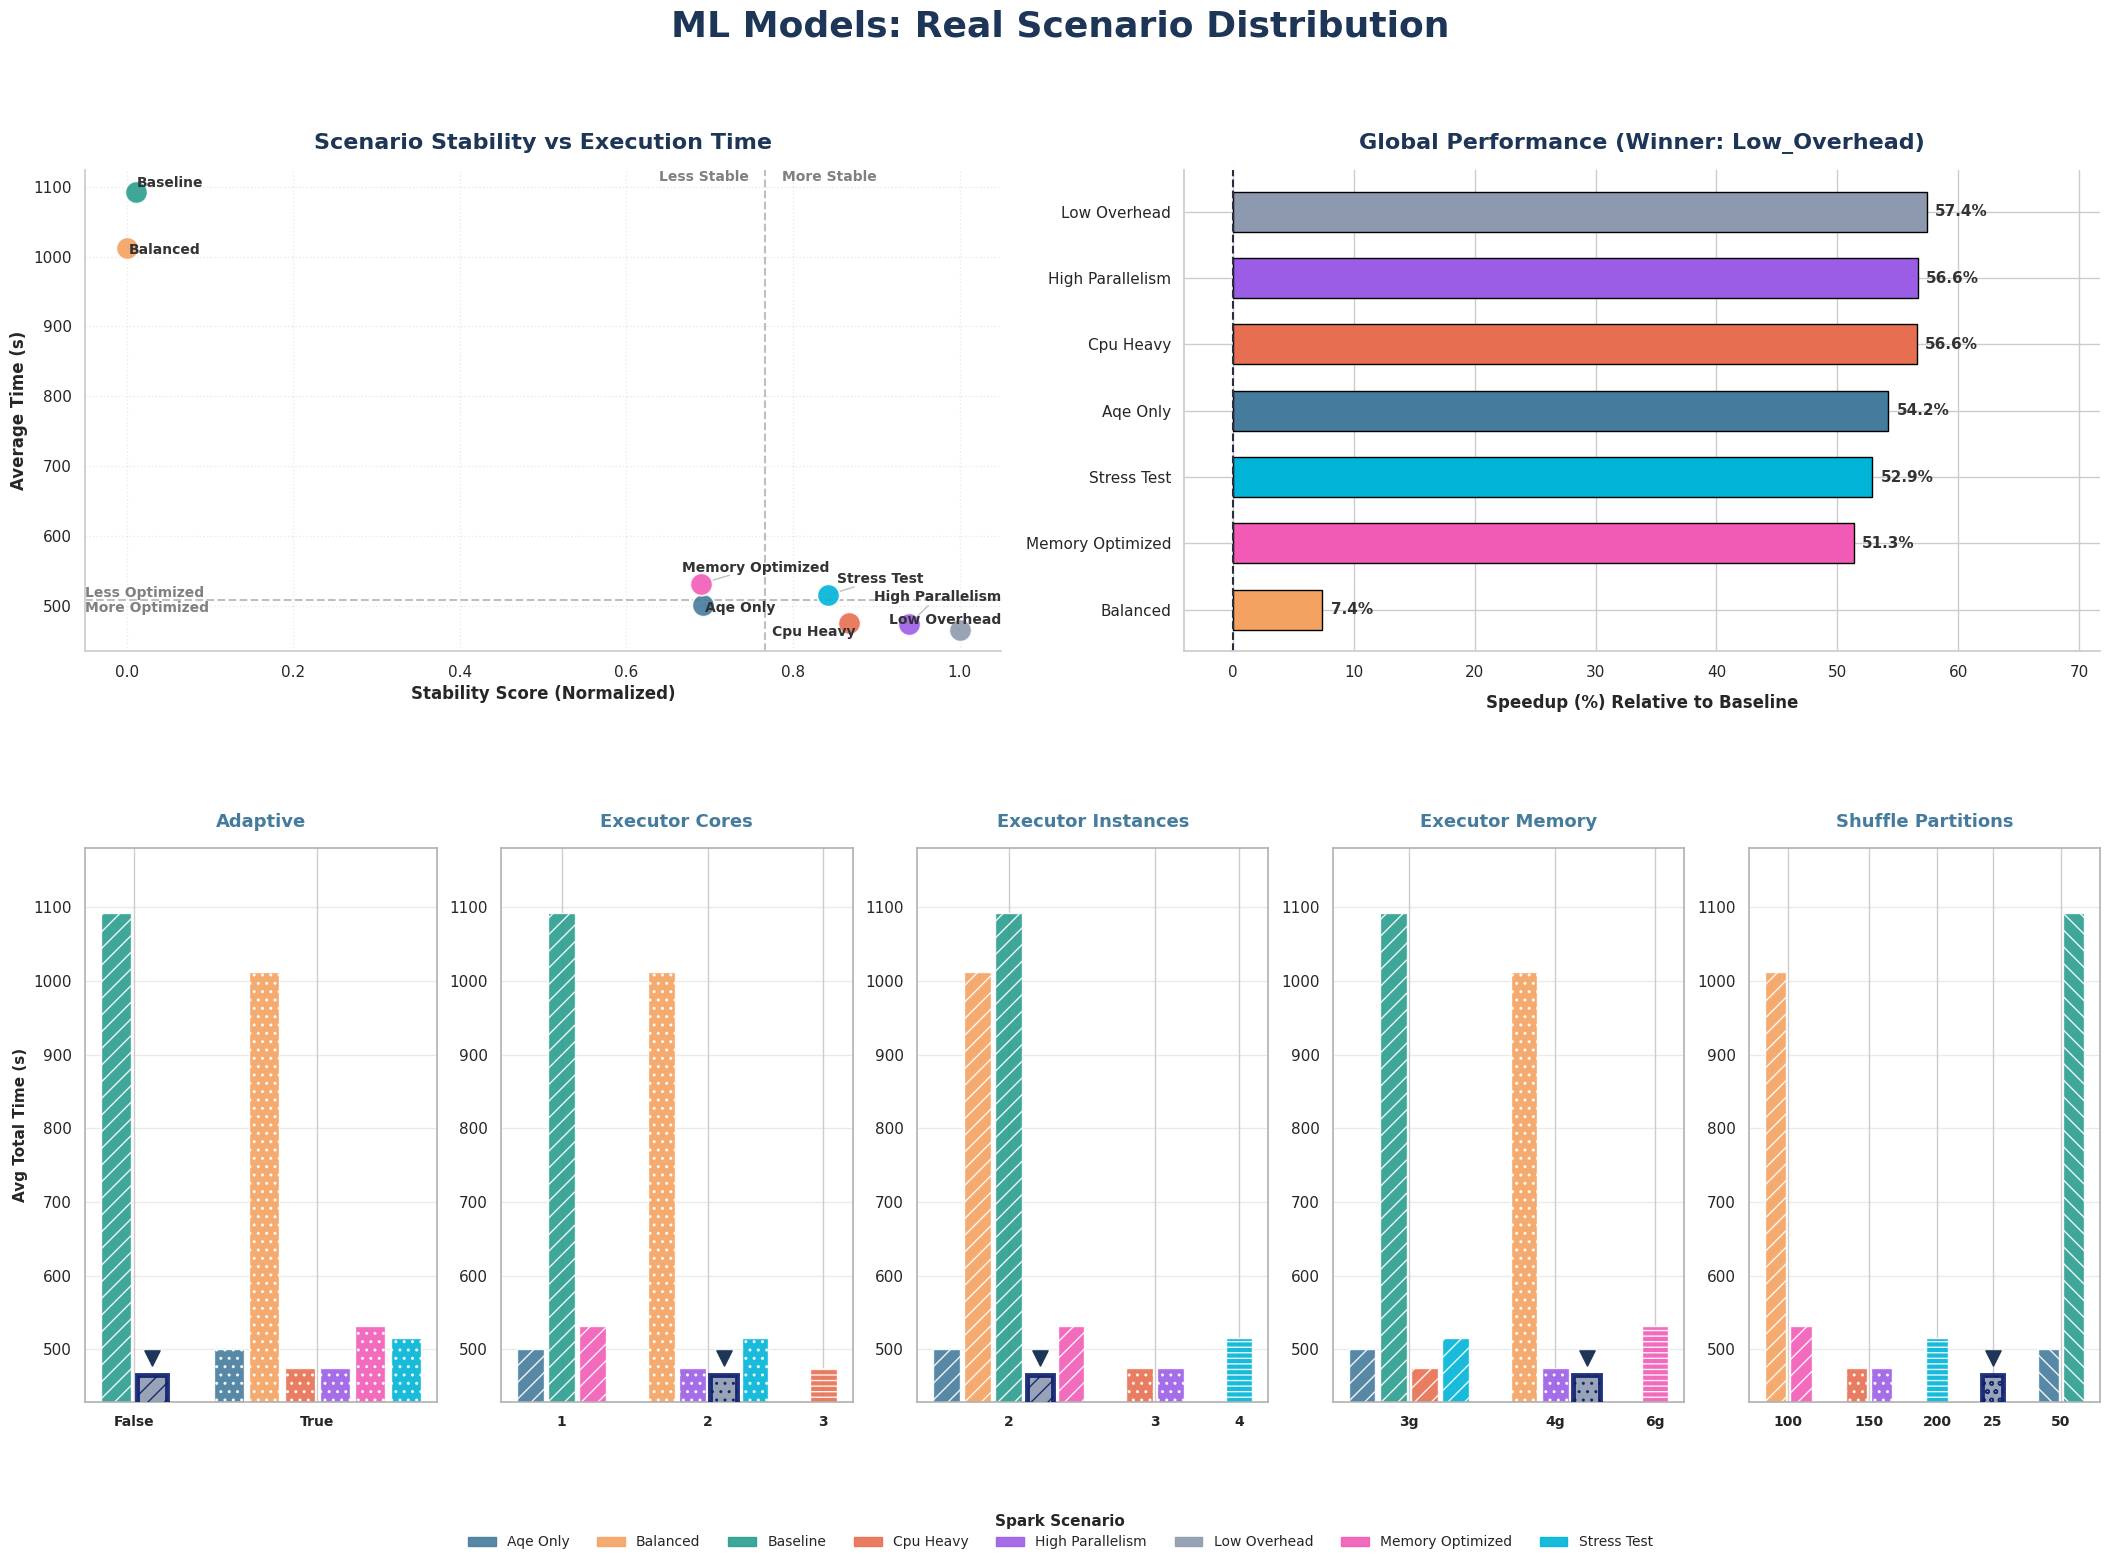

In [11]:
# Data preparation
df_m = df_models[df_models['task_type'] == 'regression'].copy()

time_col = 'execution_time_seconds'

# Global performance
scenario_perf = df_m.groupby('spark_mode')[time_col].mean().reset_index()

baseline_time = scenario_perf[
    scenario_perf['spark_mode'] == 'baseline'
][time_col].values[0]

scenario_perf['improvement_pct'] = (
    (baseline_time - scenario_perf[time_col]) / baseline_time
) * 100

scenario_perf = scenario_perf[scenario_perf['spark_mode'] != 'baseline']
scenario_perf = scenario_perf.sort_values(by='improvement_pct', ascending=True)

best_scenario_name = scenario_perf.iloc[-1]['spark_mode']

# Stability metric
stability_df = df_m.groupby("spark_mode")[time_col].agg(["mean", "std"]).reset_index()

stability_df["stability_score"] = 1 / (stability_df["std"] + 1e-6)

stability_df["stability_score_norm"] = (
    (stability_df["stability_score"] - stability_df["stability_score"].min()) /
    (stability_df["stability_score"].max() - stability_df["stability_score"].min())
)

# Scenario aggregation
component_cols = [
    'adaptive', 'executor_cores', 'executor_instances',
    'executor_memory', 'shuffle_partitions'
]

cols_to_group = ['spark_mode'] + component_cols

df_scenarios = df_m.groupby(cols_to_group)[time_col].mean().reset_index()

scenarios = sorted(df_scenarios['spark_mode'].unique())

feature_hatch_patterns = ['//', '..', '---', 'oo', '\\\\']

global_min_time = df_scenarios[time_col].min()

# Layout
fig = plt.figure(figsize=(26, 16), facecolor=BG_COLOR)

fig.suptitle("ML Models: Real Scenario Distribution", fontsize=26, fontweight='900', color='#1d3557', y=0.98)

gs_main = fig.add_gridspec(2, 1, height_ratios=[1, 1.15], hspace=0.38)
gs_top = gs_main[0].subgridspec(1, 2, wspace=0.20)
gs_bottom = gs_main[1].subgridspec(1, 10, wspace=0.45)

# Plot 1
ax_top = fig.add_subplot(gs_top[0, 0])

median_stab = stability_df["stability_score_norm"].median()
median_time = stability_df["mean"].median()

ax_top.axvline(median_stab, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
ax_top.axhline(median_time, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

texts = []
for _, row in stability_df.iterrows():
    scenario = row["spark_mode"]
    x = row["stability_score_norm"]
    y = row["mean"]

    ax_top.scatter(x, y, s=260, color=SCENARIO_COLORS.get(scenario, '#cccccc'),
                   edgecolor="white", linewidth=1.3, alpha=0.9, zorder=3)

    t = ax_top.text(x, y, scenario.replace("_", " ").title(),
                    fontsize=10, fontweight='bold', color='#333333')
    texts.append(t)

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5), ax=ax_top)

ax_top.text(median_stab - 0.02, ax_top.get_ylim()[1], "Less Stable", ha='right', va='top', fontsize=10, fontweight='bold', color='gray')
ax_top.text(median_stab + 0.02, ax_top.get_ylim()[1], "More Stable", ha='left', va='top', fontsize=10, fontweight='bold', color='gray')
ax_top.text(ax_top.get_xlim()[0], median_time + 0.2, "Less Optimized", ha='left', va='bottom', fontsize=10, fontweight='bold', color='gray')
ax_top.text(ax_top.get_xlim()[0], median_time - 0.5, "More Optimized", ha='left', va='top', fontsize=10, fontweight='bold', color='gray')

ax_top.set_title("Scenario Stability vs Execution Time", fontsize=16, fontweight='900', color='#1d3557', pad=15)
ax_top.set_xlabel("Stability Score (Normalized)", fontsize=12, fontweight='bold')
ax_top.set_ylabel("Average Time (s)", fontsize=12, fontweight='bold')
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)
ax_top.grid(axis='both', linestyle=':', alpha=0.4)

# Plot 2
ax_perf = fig.add_subplot(gs_top[0, 1])

bar_colors = [SCENARIO_COLORS.get(mode, '#cccccc') for mode in scenario_perf['spark_mode']]

bars = ax_perf.barh(scenario_perf['spark_mode'].str.replace('_', ' ').str.title(),
                    scenario_perf['improvement_pct'],
                    color=bar_colors, edgecolor='black', height=0.6)

ax_perf.axvline(0, color='#2b2d42', linestyle='--', linewidth=1.5)
ax_perf.set_xlim(min(-4, scenario_perf['improvement_pct'].min() * 1.1),
                 scenario_perf['improvement_pct'].max() * 1.25)

ax_perf.bar_label(bars, fmt='%.1f%%', padding=6, fontweight='bold', fontsize=11, color='#333333')

ax_perf.set_title(f"Global Performance (Winner: {best_scenario_name.title()})",
                  fontsize=16, color='#1d3557', fontweight='bold', pad=15)
ax_perf.set_xlabel("Speedup (%) Relative to Baseline", fontsize=12, fontweight='bold', labelpad=10)
ax_perf.spines['top'].set_visible(False)
ax_perf.spines['right'].set_visible(False)

# Bottom plots
axes = [fig.add_subplot(gs_bottom[0, i*2:(i+1)*2]) for i in range(5)]

y_min = (df_scenarios[time_col].min() * 0.92)
y_max = (df_scenarios[time_col].max() * 1.08)
y_span = y_max - y_min

for ax, comp in zip(axes, component_cols):
    df_m[comp] = df_m[comp].astype(str)
    df_scenarios[comp] = df_scenarios[comp].astype(str)

    unique_vals = sorted(df_scenarios[comp].unique())
    pattern_mapping = dict(zip(unique_vals, feature_hatch_patterns))

    x_ticks = []
    x_labels = []
    current_x = 0

    for val in unique_vals:
        subset = df_scenarios[df_scenarios[comp] == val]
        group_start = current_x

        for _, row in subset.iterrows():
            scenario = row['spark_mode']
            bar_height = row[time_col]

            is_winner = (bar_height == global_min_time)
            bar_edge_color = ("#0B1D6E" if is_winner else 'white')
            bar_line_width = (3.5 if is_winner else 1)
            z_order = (10 if is_winner else 2)

            ax.bar(current_x, bar_height, width=0.85, 
                   color=SCENARIO_COLORS.get(scenario, '#cccccc'), 
                   hatch=pattern_mapping[val], edgecolor=bar_edge_color, 
                   linewidth=bar_line_width, alpha=0.9, zorder=z_order)

            if is_winner:
                ax.scatter(current_x, bar_height + (y_span * 0.03), 
                           marker='v', color='#1d3557', s=120, zorder=20)

            current_x += 1

        group_end = current_x - 1

        if len(subset) > 0:
            x_ticks.append((group_start + group_end) / 2)
            x_labels.append(str(val))

        current_x += 1.2

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=10, fontweight='bold')
    ax.set_title(comp.replace('_', ' ').title(), fontsize=13, fontweight='bold', pad=15, color='#457b9d')
    ax.set_ylim(y_min, y_max)
    ax.grid(axis='y', linestyle='-', alpha=0.4, zorder=0)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#b0b0b0')
        spine.set_linewidth(1.2)

    if ax == axes[0]:
        ax.set_ylabel("Avg Total Time (s)", fontsize=11, fontweight='bold')
    else:
        ax.tick_params(axis='y', left=False)

# LEGEND
handles = [
    mpatches.Patch(color=SCENARIO_COLORS.get(scen, '#cccccc'),
                   label=scen.replace('_', ' ').title(), alpha=0.9)
    for scen in scenarios
]

fig.legend(
    handles=handles, title="Spark Scenario",
    title_fontproperties={'weight': 'bold', 'size': 11}, 
    loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=8, frameon=False, fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()